In [24]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from sympy.stats.sampling.sample_scipy import scipy
from scipy.optimize import differential_evolution as de
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import plotly.io as pio
pio.renderers.default = "notebook"

device = torch.device('cpu')

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

In [25]:
from add_roughness import *

z_grid_init = np.load("z_grid_init.npy")
profile_sld_re_init = np.load("profile_sld_re_init.npy")

def plot_density_profile_1(matr):
    matrix = matr.clone()
    depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
    U = (1.e-0) * matrix[:, 1].real

    x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
    y_fill = torch.repeat_interleave(U, 2)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=x_fill.detach().cpu().numpy(),
        y=y_fill.detach().cpu().numpy(),
        mode="lines",
        line=dict(color="darkgreen"),
        fill="tozeroy"
    ))
    fig.add_trace(go.Scatter(
        x=z_grid_init+15,
        y=profile_sld_re_init,
        mode="lines",
        line=dict(color="blue")
    ))

    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

plot_density_profile_1(transform_array(matr, rough_res))

In [26]:
import plotly.graph_objects as go
R_sav = np.load("R_in_savch.npy")
q_sav = np.load("q_in_savch.npy")

q = (torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.524-0.00207903*1.0e+10)
r_mod, r_mod_conv, mod_score = reflectometry(q, matr, initial_sigma1, initial_sigma2, I0, Ibkg)
exp_score = chain(torch.tensor(r0.real))


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()*1e-10,
    y=r0.real,
    mode='lines',
    line=dict(color='purple', width=2, dash='solid'),
    name='эксперимент'
))

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()[0:len(r_mod.tolist())]*1e-10,
    y=(I0*r_mod_conv).real.tolist(),
    mode='lines',
    line=dict(color='blue', width=2, dash='solid'),
    name='расчёт'
))

fig.update_layout(
    yaxis_type="log",
    xaxis_title='q, Å',
    yaxis_title='I',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.add_trace(go.Scatter(
    x=q[exp_score>0.001].cpu().detach().numpy()[0:len(r_mod[exp_score>0.001].tolist())]*1e-10,
    y=exp_score[exp_score>0.001].tolist(),
    mode='markers',
    line=dict(color='red', width=2, dash='solid'),
    name='нейро эксп'
))

fig.add_trace(go.Scatter(
    x=q[mod_score>0.001].cpu().detach().numpy()[0:len(r_mod[mod_score>0.001].tolist())]*1e-10,
    y=mod_score[mod_score>0.001].tolist(),
    mode='markers',
    line=dict(color='cyan', width=2, dash='solid'),
    name='нейро расчет'
))

score3 = torch.abs(mod_score-exp_score)
fig.add_trace(go.Scatter(
    x=q[score3>0.001].cpu().detach().numpy()[0:len(r_mod[score3>0.001].tolist())]*1e-10,
    y=score3[score3>0.001].tolist(),
    mode='markers',
    line=dict(color='orange', width=2, dash='solid'),
    name='нейро невязка'
))

fig.show()

r = torch.tensor(r0/I0.cpu().detach().numpy())

In [27]:
sum(torch.pow(mod_score-exp_score,2))

tensor(35.3740, dtype=torch.float64, grad_fn=<AddBackward0>)

In [28]:
from optimizer import *
from objective_function import *
loss_function = Comparator(q, r)

In [29]:
from variables import *
x_d = initial_d.reshape(-1, 5)[:, 0:2].flatten()

In [30]:
objective_function1 = loss_function.compare
loss1 = objective_function1(matr, sigma1, sigma2, I0, Ibkg, ref_type='model')

loss1

tensor(41.5691, dtype=torch.float64, grad_fn=<AddBackward0>)

Optimizing: 100%|████████████████████████████████████████████████████████| 600/600 [08:18<00:00,  1.20it/s, lr=3.08e-02]


Stage 1: Learning Rate=0.02, Iterations=600, relative_loss=0.18953198696429574


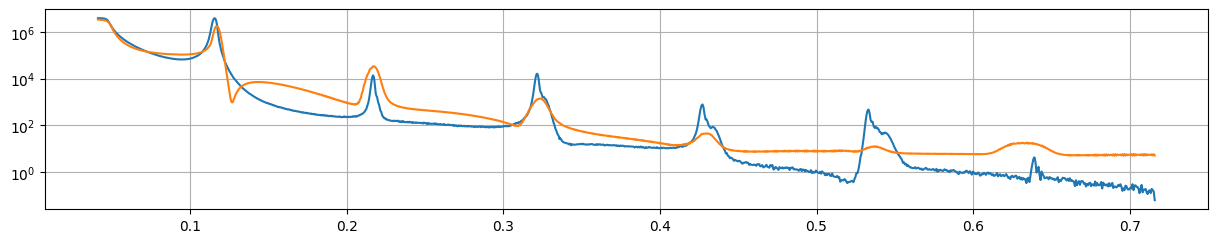

Optimizing: 100%|██████████████████████████████████████████████████████| 1200/1200 [16:31<00:00,  1.21it/s, lr=1.41e-02]


Stage 2: Learning Rate=0.012, Iterations=1200, relative_loss=0.6341714542141831


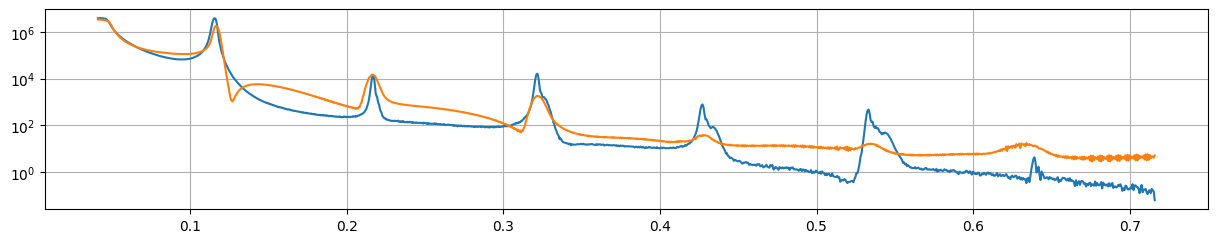

Optimizing: 100%|██████████████████████████████████████████████████████| 1200/1200 [17:45<00:00,  1.13it/s, lr=1.41e-02]


Stage 3: Learning Rate=0.012, Iterations=1200, relative_loss=0.35685207069059127


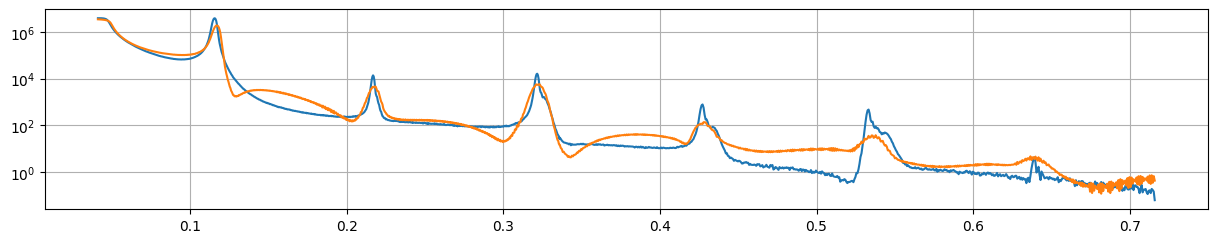

Optimizing: 100%|██████████████████████████████████████████████████████| 1200/1200 [17:16<00:00,  1.16it/s, lr=1.17e-02]


Stage 4: Learning Rate=0.01, Iterations=1200, relative_loss=0.19806568689344914


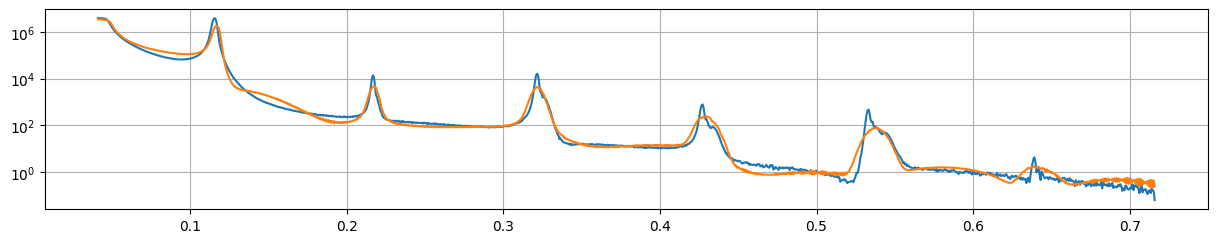

Optimizing: 100%|██████████████████████████████████████████████████████| 1200/1200 [16:49<00:00,  1.19it/s, lr=1.17e-02]


Stage 5: Learning Rate=0.01, Iterations=1200, relative_loss=0.8227579115289069


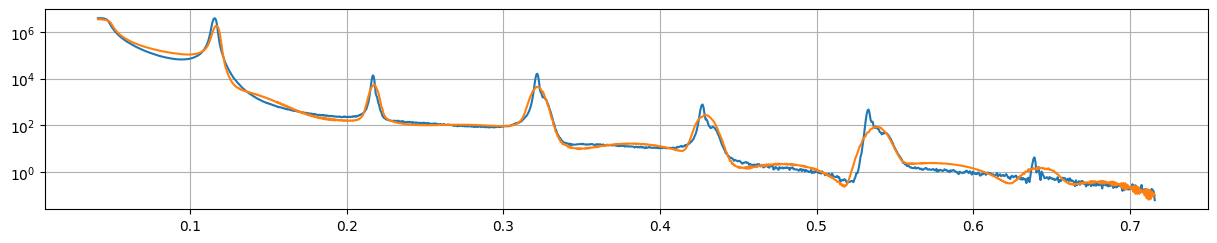

Optimizing: 100%|██████████████████████████████████████████████████████| 1200/1200 [16:40<00:00,  1.20it/s, lr=1.17e-02]


Stage 6: Learning Rate=0.01, Iterations=1200, relative_loss=0.7654626373332033


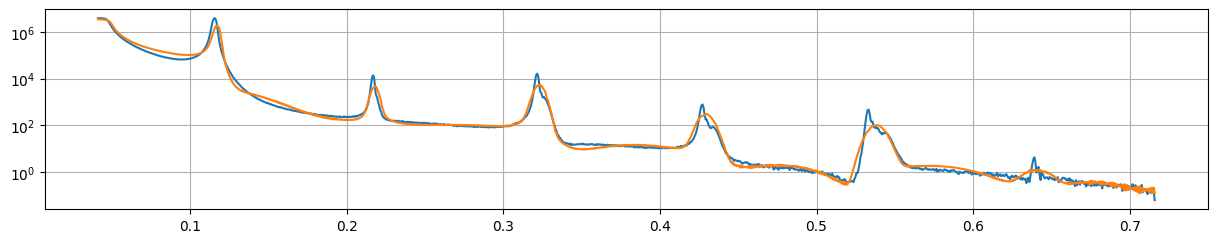

Optimizing: 100%|████████████████████████████████████████████████████████| 300/300 [04:09<00:00,  1.20it/s, lr=1.76e-02]


Stage DE 1: Learning Rate=0.01, Iterations=300.0, relative_loss=1.3075700827942012, sigma1= 0.013244094933004671, sigma2= 0.02263911570738351


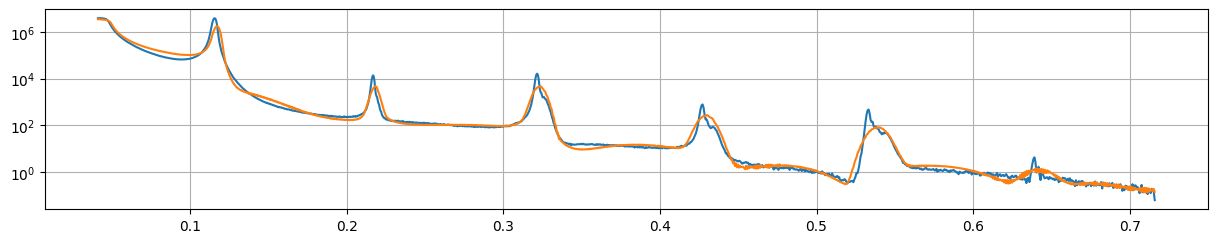

Optimizing: 100%|████████████████████████████████████████████████████████| 300/300 [04:10<00:00,  1.20it/s, lr=1.76e-02]


Stage DE 2: Learning Rate=0.01, Iterations=300.0, relative_loss=0.9044424587955305, sigma1= 0.01764057012441784, sigma2= 0.02031107208788254


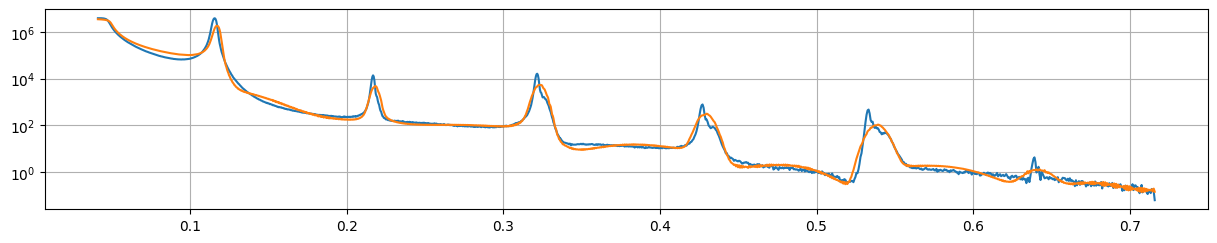

Optimizing: 100%|████████████████████████████████████████████████████████| 300/300 [04:08<00:00,  1.21it/s, lr=1.76e-02]


Stage DE 3: Learning Rate=0.01, Iterations=300.0, relative_loss=1.500290207163221, sigma1= 0.013494569691974682, sigma2= 0.02432871704028477


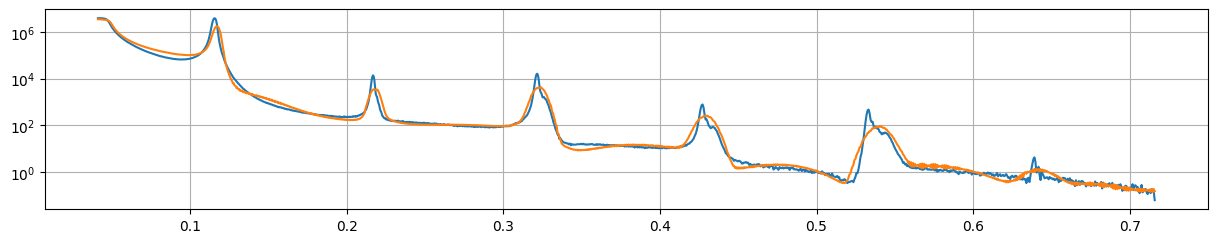

Optimizing: 100%|████████████████████████████████████████████████████████| 300/300 [04:13<00:00,  1.18it/s, lr=1.76e-02]


Stage DE 4: Learning Rate=0.01, Iterations=300.0, relative_loss=1.2418355901344345, sigma1= 0.012379215779818317, sigma2= 0.024329014139296126


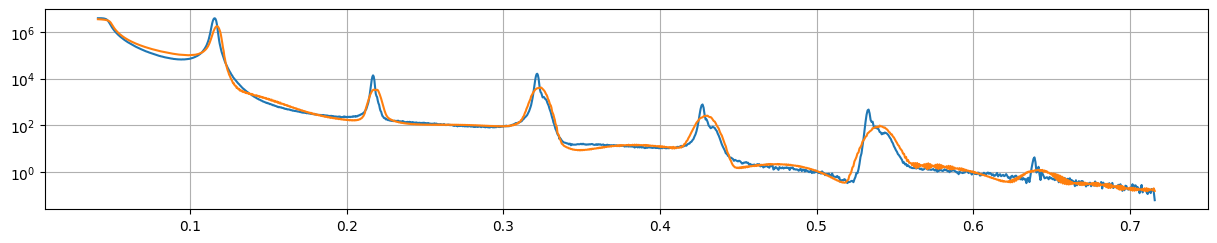

In [31]:
loss_classes = [
    varbounds(all_bounds, loss_function.compare, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_08, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_05, 0.2, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_025, 0.1, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_025, 0.1, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_weightless, 0.06, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_weightless, 0.06, matr, sigma1, sigma2, I0, Ibkg, ref_type='model')
]

learning_rates = [0.02, 0.012, 0.012,0.01, 0.01,0.01, 0.002]
iterations = [600, 1200, 1200, 1200, 1200, 1200, 1200]
#betas=(0.9655, 0.99)

ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, ans_sigma1, ans_sigma2, loss, rel_losses = pie_optimizer(q, r, (0.36, 0.996),    0.991,
 0.004, initial_d, initial_r_rho, initial_i_rho, I0, Ibkg, initial_sigma1, initial_sigma2,
    learning_rates,
    iterations,
    loss_classes
)

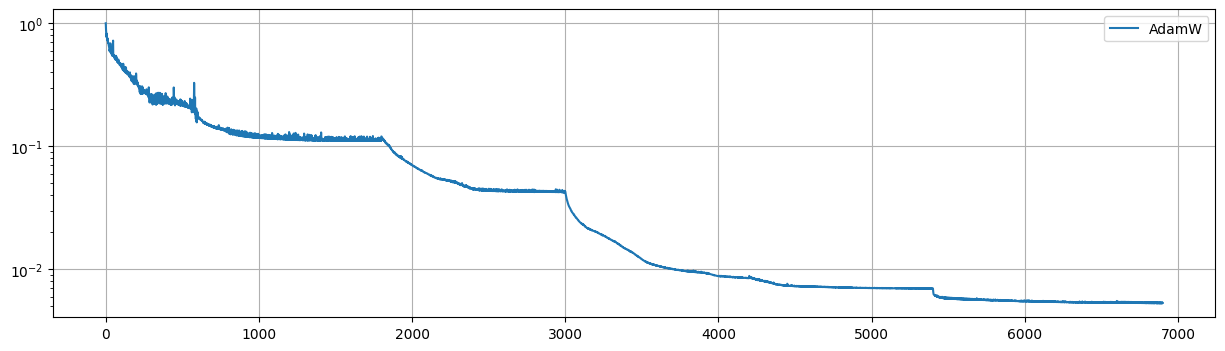

In [32]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [33]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,
                       torch.tensor([0, 5, 1, 2, 3, 4])]
r_mod, r_mod_conv, score= reflectometry(q, torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), ans_sigma1, ans_sigma2, I0, Ibkg)
score2 = chain(torch.tensor(r0))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()*1e-10,
    y=r0.real,
    mode='lines',
    line=dict(color='purple', width=2, dash='solid'),
    name='эксперимент'
))

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10,
    y=(I0*r_mod_conv).real.tolist(),
    mode='lines',
    line=dict(color='blue', width=2, dash='solid'),
    name='расчёт'
))

fig.add_trace(go.Scatter(
    x=q[score2>0.001].cpu().detach().numpy()[0:len(r_mod[score2>0.001].tolist())]*1e-10,
    y=score2[score2>0.001].tolist(),
    mode='markers',
    line=dict(color='red', width=2, dash='solid'),
    name='нейро эксп'
))

fig.add_trace(go.Scatter(
    x=q[score>0.001].cpu().detach().numpy()[0:len(r_mod[score>0.001].tolist())]*1e-10,
    y=score[score>0.001].tolist(),
    mode='markers',
    line=dict(color='cyan', width=2, dash='solid'),
    name='нейро расчет'
))

score3 = torch.abs(score-score2)
fig.add_trace(go.Scatter(
    x=q[score3>0.001].cpu().detach().numpy()[0:len(r_mod[score3>0.001].tolist())]*1e-10,
    y=score3[score3>0.001].tolist(),
    mode='markers',
    line=dict(color='orange', width=2, dash='solid'),
    name='нейро невязка'
))


fig.update_layout(
    yaxis_type="log",
    xaxis_title='q, Å',
    yaxis_title='I',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

In [34]:
sum(torch.pow(score2-score,2))

tensor(9.7470, dtype=torch.float64, grad_fn=<AddBackward0>)

In [35]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,torch.tensor([0, 5, 1, 2,3,4])]
fig = plot_density_profile(transform_array(torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), rough_res))
fig.show()

In [36]:
np_bounds = np.array([
    [15.0, 90.0], [6.0, 90.0],
    [20.0, 90.0], [6.0, 80.0],
    [15.0, 90.0], [6.0, 90.0],
    [20.0, 90.0], [6.0, 80.0]
])

var_vector = combined_x_for_print.real[2:-1, [0,2]].flatten().detach().numpy()

n_walkers = 24

sc = 0.001
sc_add = 0.0001

position = np.transpose(np.repeat(var_vector.reshape(-1, 1), n_walkers, axis = 1))

position+=position*(sc*np.random.rand(n_walkers, var_vector.shape[0])-sc/2)+(sc_add*np.random.rand(n_walkers, var_vector.shape[0])-sc_add/2)

vv = torch.tensor(var_vector)

In [39]:
from calculating_dynamic_resolution import resolution_function_smooth_step
sigmas = []
for q_i in q:
    sigmas.append(resolution_function_smooth_step(q[-1], q_i, sigma1, sigma2, gap).cpu().detach().numpy())
sigmas = np.array(sigmas)

def log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas=None):
    var_vector = torch.tensor(theta)
    q = q.cpu().detach().numpy()
    r_exp = r_exp.cpu().detach().numpy()

    matr_untr = torch.cat((torch.cat((ans_d.reshape(-1,5)[[0,1], 0:2], var_vector.reshape(-1,2), ans_d.reshape(-1,5)[[-1], 0:2]), dim=0), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1), ans_d.reshape(-1,5)[:, [2,3,4]]), dim=1)[:, [0,2,1,3,4,5]]
    new_matr = torch.cat((matr[[0], :], matr_untr), dim=0)

    _, r_model, score_model  = reflectometry(q, new_matr, sigma1, sigma2, I0, Ibkg)
    score_exper = chain(torch.tensor(r_exp)).detach().numpy()
    score_model = score_model.detach().numpy()
    if isinstance(r_model, torch.Tensor):
         r_model = r_model.real.cpu().detach().numpy()

    r_min = np.minimum(r_exp, r_model)
    #print(np.sum(((r_exp - r_model)/r_min)**2), np.sum(np.pow(score_model-score_exper,2)))

    return -0.5 * (np.sum(((r_exp - r_model)/r_min)**2) + 20*np.sum(np.pow(score_model-score_exper,2)))


def log_prior(theta):
    summa = 0

    for o, x in enumerate(theta):
        if (np_bounds[o,0]> x or x > np_bounds[o,1]):
            summa+=1

    if summa>0:
        return -np.inf
    return 0



def log_probability(theta, I0, Ibkg, q, r_exp, sigmas=None):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas)

In [40]:
import emcee

nwalkers, ndim = position.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(I0, Ibkg, q, r, sigmas)
)
sampler.run_mcmc(position, 1600, progress=True);

100%|██████████| 1600/1600 [3:30:31<00:00,  7.89s/it]  


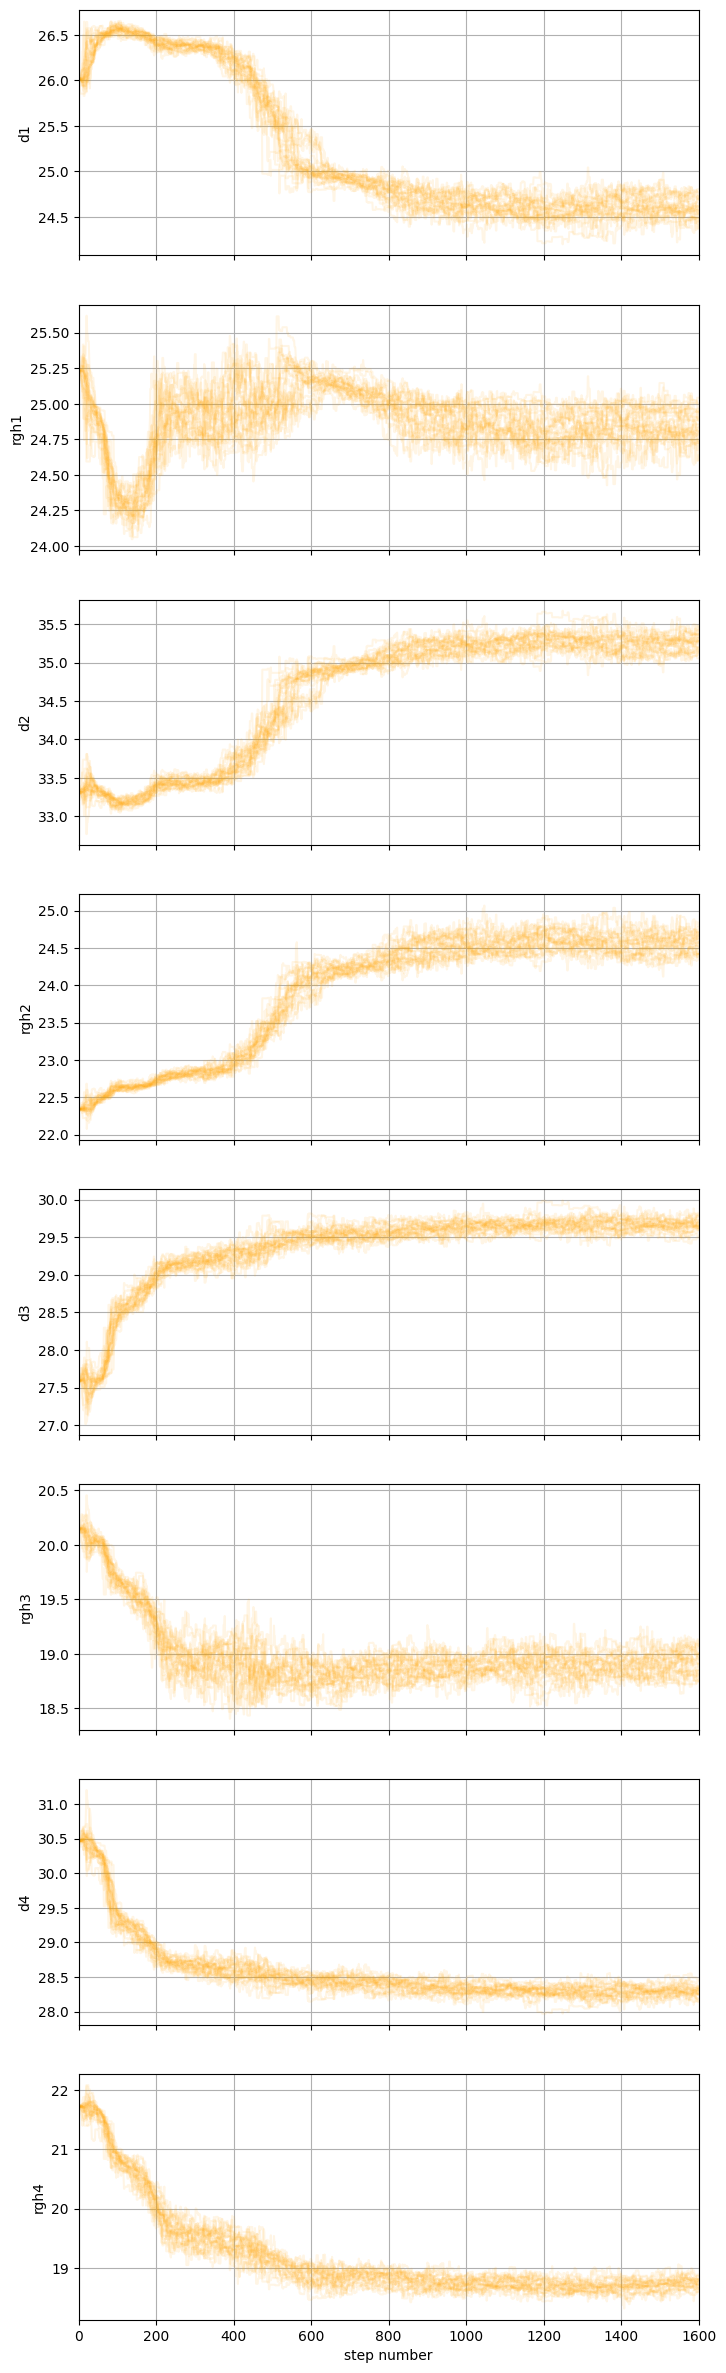

In [41]:
fig, axes = plt.subplots(8, figsize=(8, 30), sharex=True)
samples = sampler.get_chain()
labels = ["d1", "rgh1", "d2", "rgh2", "d3", "rgh3", "d4", "rgh4"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.1, color='orange')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.grid(True)

axes[-1].set_xlabel("step number");

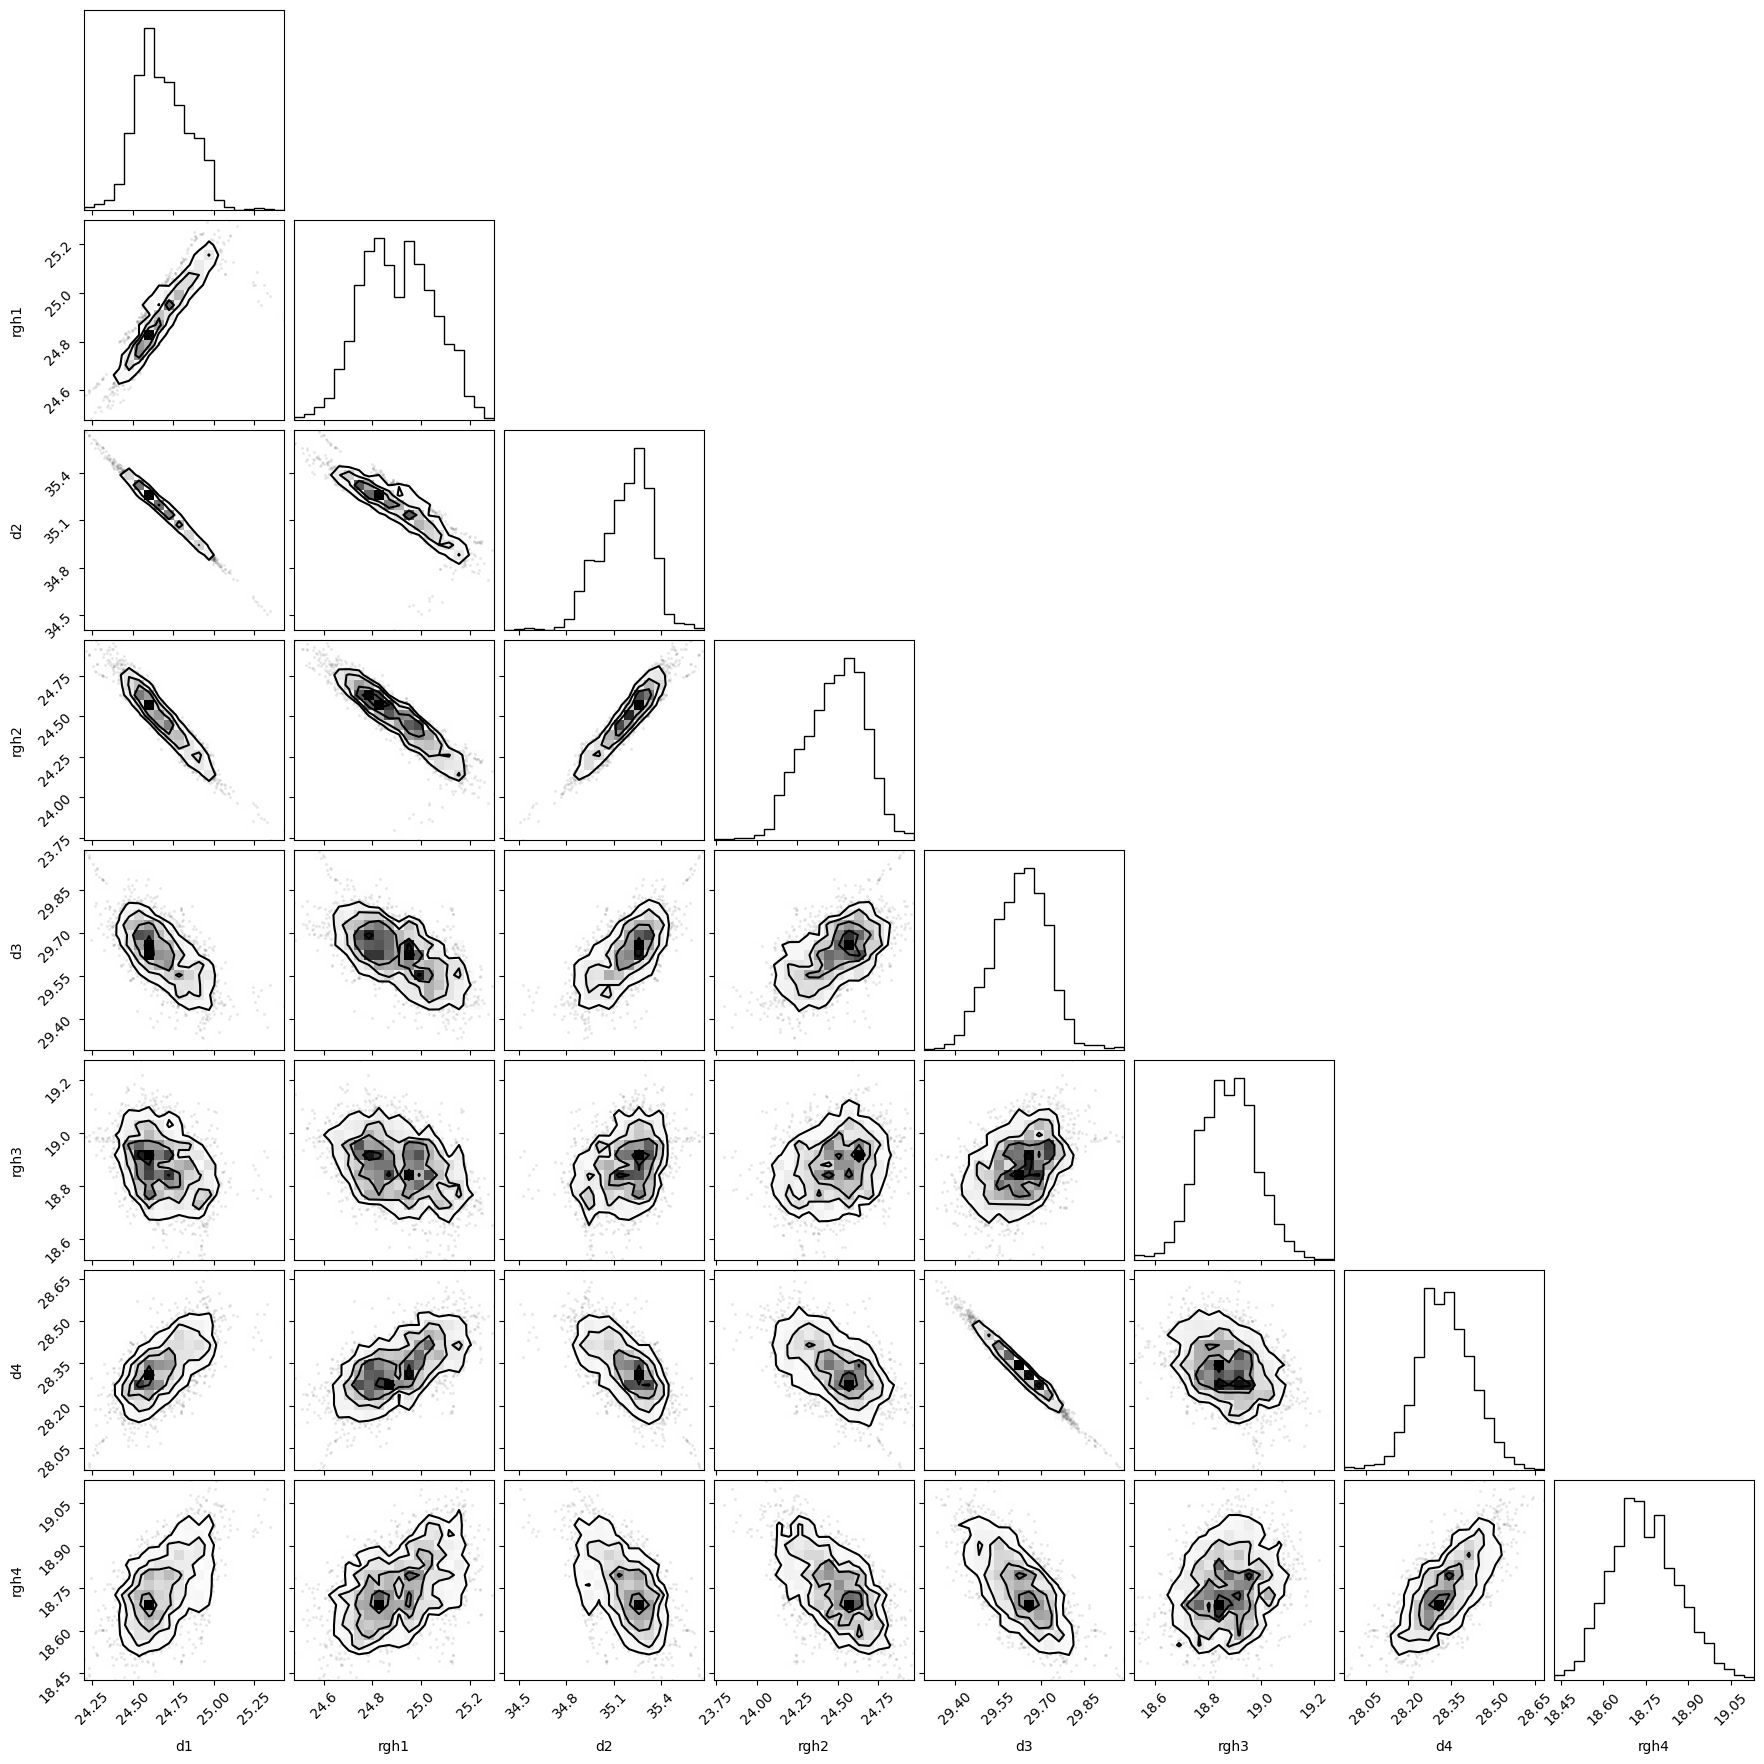

In [47]:
flat_samples = sampler.get_chain(discard=600, thin=10, flat=True)
import corner

fig = corner.corner(
    flat_samples, labels=labels
)

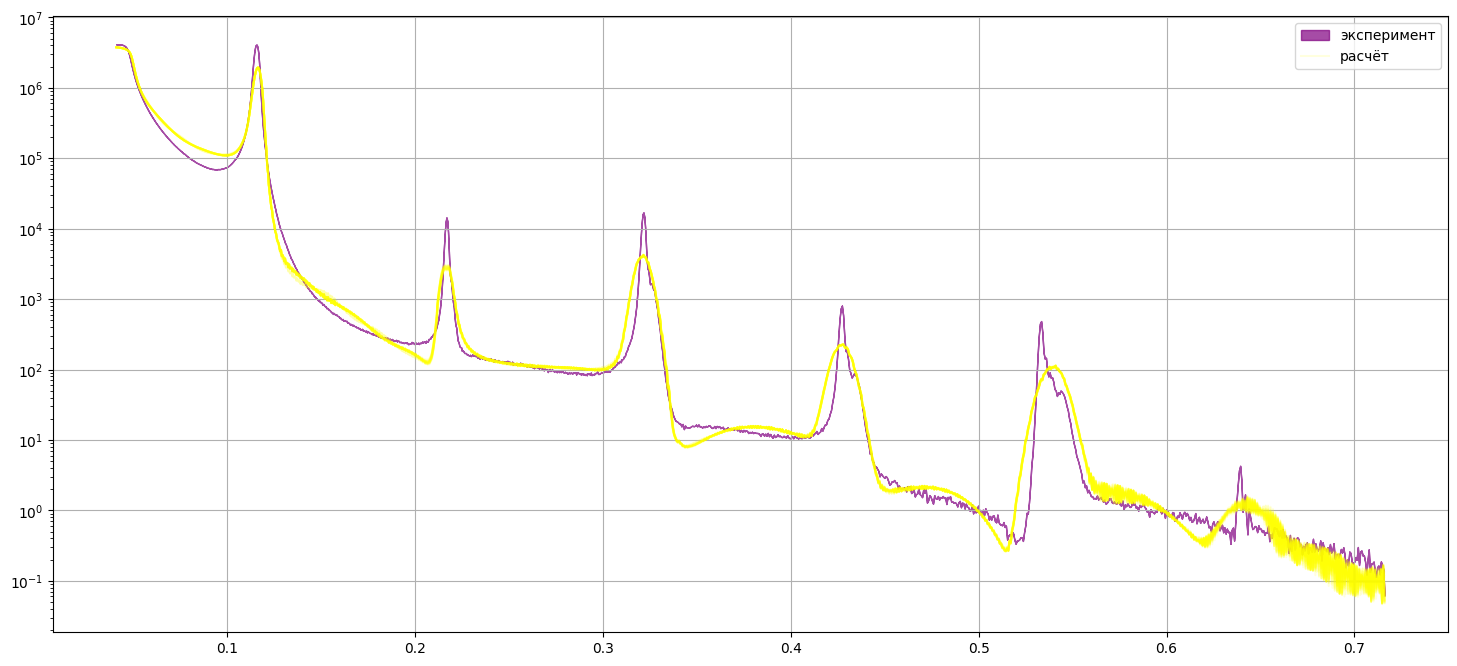

In [43]:
final_samples = samples[-1, :, :]
r_mod_list = []
matr_mod_list = []

for sample in final_samples:
    var_vector = torch.tensor(sample)

    x_matr =torch.cat((torch.cat((ans_d.reshape(-1,5)[[0,1], 0:2], var_vector.reshape(-1,2), ans_d.reshape(-1,5)[[-1], 0:2]), dim=0), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1), ans_d.reshape(-1,5)[:, [2,3,4]]), dim=1)[:, [0,2,1,3,4,5]]
    new_matr = torch.cat((matr[[0], :], x_matr), dim=0)

    _, r_mod_conv2, _ = reflectometry(q, new_matr, ans_sigma1, ans_sigma2, I0, Ibkg)
    r_mod_list.append(r_mod_conv2)
    matr_mod_list.append(transform_array(new_matr, rough_res))

fig, ax = plt.subplots(figsize=(18, 8))

# Заливка для экспериментальных данных
ax.fill_between(q*1e-10, r0, r0, color='purple', alpha=0.7, label='эксперимент')

# Отрисовка всех графиков из r_mod_list
for r_mod_conv2 in r_mod_list:
    ax.plot(q[0:len(r_mod_conv2.tolist())]*1e-10, (I0*r_mod_conv2).tolist(), color='yellow', alpha=0.13, label='расчёт' if r_mod_conv2 is r_mod_list[0] else None)

# Настройки осей и легенды
ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [46]:
def plot_density_profile_variator(matr_list):
    fig = go.Figure()

    # Проходим по каждому тензору в списке
    for matr in matr_list:
        matrix = torch.tensor(matr)
        depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
        U = (1.e-0) * matrix[:, 1].real

        x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
        y_fill = torch.repeat_interleave(U, 2)

        # Добавляем график с полупрозрачностью и одинаковым цветом
        fig.add_trace(go.Scatter(
            x=x_fill.detach().cpu().numpy(),
            y=y_fill.detach().cpu().numpy(),
            mode="lines",
            line=dict(color="darkgreen"),
            opacity=0.8,  # Полупрозрачность
            showlegend=(matr is matr_list[0])  # Показываем легенду только для первого графика
        ))

    # Настройки осей и макета
    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

fig = plot_density_profile_variator(matr_mod_list)
fig.show()